# Fairness audit - readmission model by race (idea A)
Does the within-30d model treat race groups equally, and does race even matter?
Two outputs: per-group FPR/FNR/recall, and a clean with/without-race ablation.
Retires the earlier unverified race numbers. Reads `patient_first_visit.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

DATA_DIR = "/Users/robert/Desktop/hospital-re-admission/data/processed"
RESULTS_DIR = "/Users/robert/Desktop/hospital-re-admission/notebooks/18_fairness_audit"
SEED = 42

## Group the 33 race labels into 5
Collapse the free-text race field into White/Black/Hispanic/Asian/Other.
Needed for group sizes big enough to measure fairness.

In [2]:
df = pd.read_csv(f"{DATA_DIR}/patient_first_visit.csv")

def race_group(r):
    r = str(r)
    if r.startswith("WHITE") or r == "PORTUGUESE": return "White"
    if r.startswith("BLACK"): return "Black"
    if "HISPANIC" in r or "LATINO" in r: return "Hispanic"
    if r.startswith("ASIAN"): return "Asian"
    return "Other/Unknown"
df["rgrp"] = df["race"].map(race_group)
print(df["rgrp"].value_counts())

rgrp
White            119770
Black             22795
Other/Unknown     21036
Hispanic           9275
Asian              7476
Name: count, dtype: int64


## Train the within-30d model
Same recipe as NB14b (balanced weights, patient-level split).
Then score every race group separately.

In [3]:
cat_cols = ["gender", "race", "marital_status", "language", "insurance",
            "admission_type", "admission_location", "discharge_location"]
drop_cols = ["subject_id", "hadm_id", "tgt_bucket", "tgt_days", "visit_num", "split", "rgrp"]
features = [c for c in df.columns if c not in drop_cols]
is_train = df["split"].values == "train"

X = df[features].copy()
for c in cat_cols:
    m = {v: i for i, v in enumerate(sorted(X.loc[is_train, c].astype(str).unique()))}
    X[c] = X[c].astype(str).map(m).fillna(-1).astype(int)
y = (df["tgt_days"] <= 30).fillna(False).astype(int).values

def new_model():
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
                         colsample_bytree=0.8, eval_metric="logloss", tree_method="hist",
                         random_state=SEED, n_jobs=4)

clf = new_model()
clf.fit(X[is_train], y[is_train], sample_weight=compute_sample_weight("balanced", y[is_train]))
proba = clf.predict_proba(X[~is_train])[:, 1]
pred = (proba >= 0.5).astype(int)
yte = y[~is_train]; grp = df.loc[~is_train, "rgrp"].values

In [4]:
groups = ["White", "Black", "Hispanic", "Asian", "Other/Unknown"]
rows = []
for gname in groups:
    mask = grp == gname
    yy, pp, pr = yte[mask], pred[mask], proba[mask]
    tn, fp, fn, tp = confusion_matrix(yy, pp, labels=[0, 1]).ravel()
    rows.append({"group": gname, "n": int(mask.sum()),
                 "base_rate": round(yy.mean(), 3),
                 "auroc": round(roc_auc_score(yy, pr), 3),
                 "fpr": round(fp / (fp + tn), 3),
                 "fnr": round(fn / (fn + tp), 3),
                 "recall": round(tp / (tp + fn), 3),
                 "selection_rate": round(pp.mean(), 3)})
fair = pd.DataFrame(rows)
print(fair.to_string(index=False))
fair.to_csv(f"{RESULTS_DIR}/fairness_by_race.csv", index=False)

        group     n  base_rate  auroc   fpr   fnr  recall  selection_rate
        White 23775      0.128  0.668 0.311 0.449   0.551           0.342
        Black  4643      0.125  0.671 0.224 0.553   0.447           0.252
     Hispanic  1853      0.113  0.678 0.198 0.571   0.429           0.225
        Asian  1500      0.115  0.712 0.235 0.480   0.520           0.268
Other/Unknown  4300      0.079  0.722 0.116 0.631   0.369           0.136


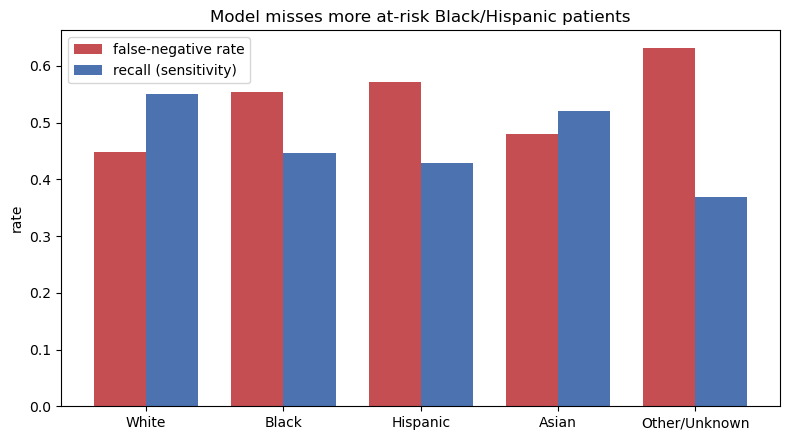

In [5]:
# Graph: false-negative rate and recall by group (the equal-opportunity view).
x = np.arange(len(groups)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, fair["fnr"], w, label="false-negative rate", color="#c44e52")
ax.bar(x + w/2, fair["recall"], w, label="recall (sensitivity)", color="#4c72b0")
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel("rate"); ax.legend()
ax.set_title("Model misses more at-risk Black/Hispanic patients")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/fairness_fnr_recall.png", dpi=150); plt.show()

## Does race even matter? (ablation)
Retrain with race removed and compare AUROC.
This is the clean number that replaces the earlier unverified claims.

In [6]:
clf_nr = new_model()
Xnr = X.drop(columns=["race"])
clf_nr.fit(Xnr[is_train], y[is_train], sample_weight=compute_sample_weight("balanced", y[is_train]))
auroc_with = roc_auc_score(yte, proba)
auroc_without = roc_auc_score(yte, clf_nr.predict_proba(Xnr[~is_train])[:, 1])
print(f"with race:    AUROC {auroc_with:.4f}")
print(f"without race: AUROC {auroc_without:.4f}")
print(f"delta:        {auroc_with - auroc_without:+.4f}  (negligible - race is not a strong driver)")

with race:    AUROC 0.6817
without race: AUROC 0.6787
delta:        +0.0030  (negligible - race is not a strong driver)
